# Career Predictor — AI Dependency & Career Anxiety in Students

This notebook builds a **multi-target prediction pipeline** on the *AI Dependency & Career Anxiety in Students* dataset. Three separate models are trained:

| Target | Type | Objective |
|--------|------|-----------|
| `burnout_score` | Regression | Predict student burnout level |
| `overall_career_readiness_score` | Regression | Predict career readiness |
| `seeks_career_counseling` | Binary Classification | Predict whether a student will seek counseling |

The pipeline follows these phases:
1. Library imports
2. Data ingestion & train/test split
3. Exploratory data analysis (EDA) & missing-value imputation
4. Feature engineering & encoding
5. Distribution analysis & correlation
6. Target separation & feature scaling
7. Multicollinearity check (VIF)
8. Feature selection via Weight of Evidence / Information Value
9. Model training & Optuna hyperparameter tuning per target
10. Model serialisation

## 1. Library Imports

All dependencies are loaded upfront so that missing packages surface immediately.

| Library | Role |
|---------|------|
| `numpy`, `pandas` | Numerical computation and tabular data handling |
| `seaborn`, `matplotlib` | Statistical and distribution visualisations |
| `shap` | Model explainability (SHAP values) |
| `math` | Grid layout arithmetic for subplot grids |
| `statsmodels` VIF | Variance Inflation Factor for multicollinearity detection |
| `sklearn` | Train/test split, scalers, linear & ensemble models, metrics |
| `xgboost` | Gradient-boosted trees for regression and classification |
| `optuna` | Bayesian hyperparameter optimisation |

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import math
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
import optuna
import shap

C:\Users\soham\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Ingestion

The dataset is loaded from a local CSV file. The first five rows are displayed to verify column names, data types, and a sample of values.

In [2]:
df = pd.read_csv("ai_dependency_career_anxiety_students.csv")

df.head()

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


## 3. Train / Test Split (Upstream, Before Any EDA)

The dataset is split **before** any imputation or transformation. This is intentional — it prevents **data leakage**, ensuring that statistics computed during EDA (e.g. medians, modes) are derived exclusively from the training set and never contaminated by test-set information.

In [3]:
df_train, df_test = train_test_split(df, test_size=0.3)

In [4]:
print(df_train.shape)
print(df_test.shape)

(10500, 30)
(4500, 30)


## 4. Initial Data Inspection

`DataFrame.info()` provides a column-level summary including dtypes, non-null counts, and memory usage. This reveals which columns have missing values and whether any columns have unexpected dtypes.

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10500 entries, 691 to 11843
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       10500 non-null  object 
 1   age                              10500 non-null  int64  
 2   gender                           10500 non-null  object 
 3   degree_type                      10500 non-null  object 
 4   stream                           10500 non-null  object 
 5   year_of_study                    10500 non-null  int64  
 6   college_tier                     10500 non-null  object 
 7   urban_or_rural                   10500 non-null  object 
 8   daily_ai_tool_usage_hrs          10500 non-null  float64
 9   primary_ai_tools_used            8288 non-null   object 
 10  uses_ai_for_assignments          10500 non-null  object 
 11  ai_replaces_own_thinking_score   10500 non-null  int64  
 12  ai_dependency_score  

## 5. Missing Value Analysis

Only columns with at least one missing value are visualised. A horizontal bar chart is used so column names remain legible regardless of count.

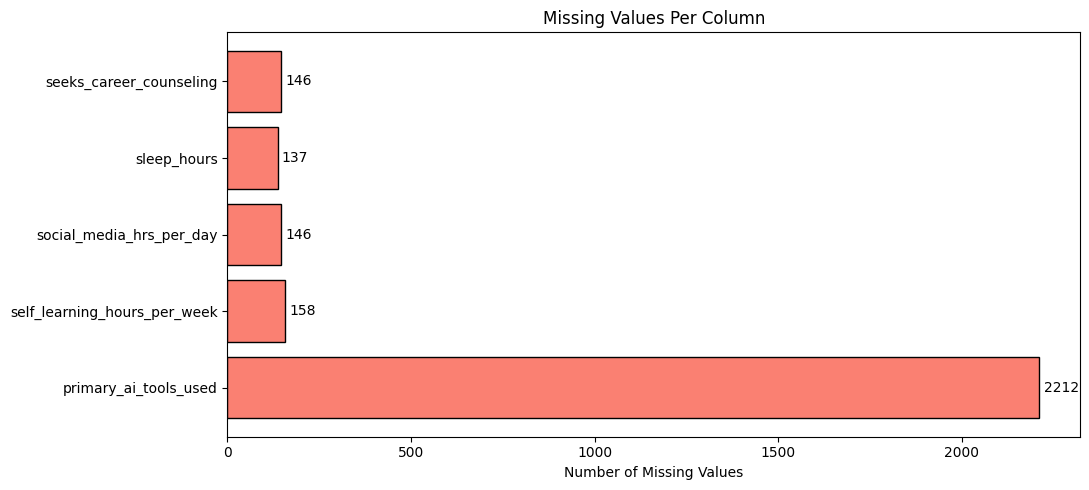

In [6]:
missing = df_train.isna().sum()
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(missing.index, missing.values, color='salmon', edgecolor='black')
ax.bar_label(bars, padding=3)
ax.set_xlabel('Number of Missing Values')
ax.set_title('Missing Values Per Column')
plt.tight_layout()
plt.show()

## 6. Imputation — `primary_ai_tools_used` (Categorical)

This column's missingness is **not random** — it is structurally linked to `daily_ai_tool_usage_hrs`:

- If `daily_ai_tool_usage_hrs == 0` → the student uses no AI tools → fill with `'None'`.
- If `daily_ai_tool_usage_hrs > 0` → the student uses AI but the tool is unrecorded → fill with `'Unknown'`.

This logic-driven approach preserves meaningful signal rather than collapsing everything into a single imputed category. The same logic is applied separately to train and test sets.

In [7]:
df_train.primary_ai_tools_used.value_counts()

primary_ai_tools_used
ChatGPT           3838
Gemini            1737
Claude            1351
Perplexity         726
GitHub Copilot     636
Name: count, dtype: int64

In [8]:
mask_none = (
    df_train['primary_ai_tools_used'].isna() &
    (df_train['daily_ai_tool_usage_hrs'] == 0)
)

mask_unknown = (
    df_train['primary_ai_tools_used'].isna() &
    (df_train['daily_ai_tool_usage_hrs'] > 0)
)

df_train.loc[mask_none, 'primary_ai_tools_used'] = 'None'
df_train.loc[mask_unknown, 'primary_ai_tools_used'] = 'Unknown'

In [9]:
mask_none = (
    df_test['primary_ai_tools_used'].isna() &
    (df_test['daily_ai_tool_usage_hrs'] == 0)
)

mask_unknown = (
    df_test['primary_ai_tools_used'].isna() &
    (df_test['daily_ai_tool_usage_hrs'] > 0)
)

df_test.loc[mask_none, 'primary_ai_tools_used'] = 'None'
df_test.loc[mask_unknown, 'primary_ai_tools_used'] = 'Unknown'

## 7. Numeric Columns with Missing Values — Distribution Inspection

Before choosing a fill strategy, the distribution shape of each numeric column with missingness is examined:

- **Symmetric distributions** → mean imputation is acceptable.
- **Skewed distributions** → **median imputation** is preferred, as the mean is pulled toward the tail and would introduce bias.

This step informs the decision made in the next cell.

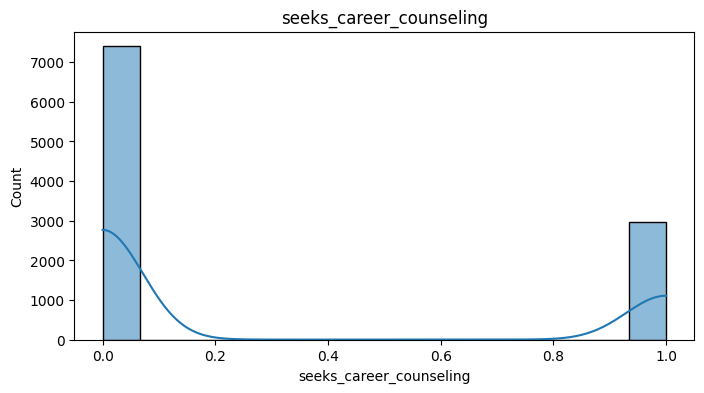

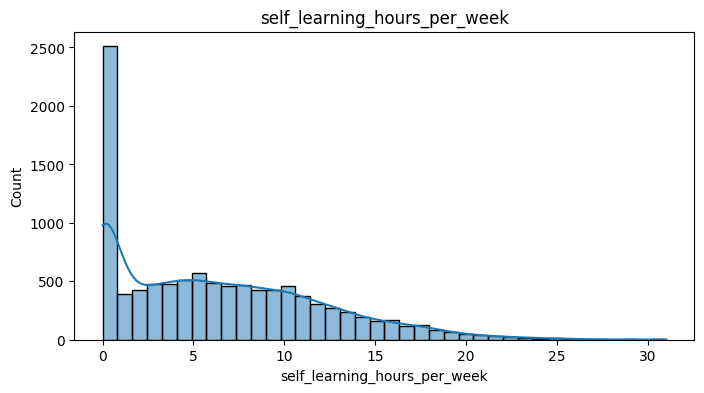

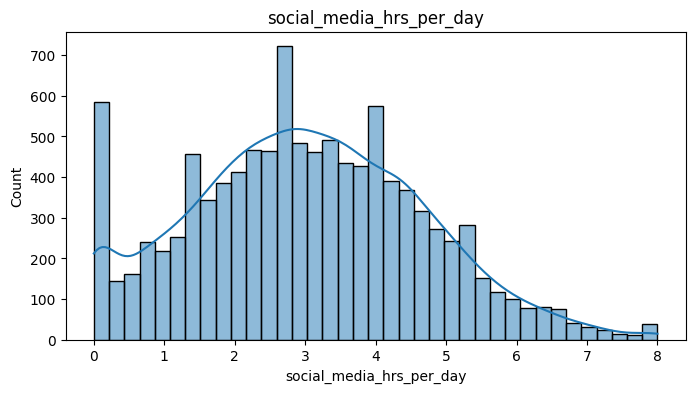

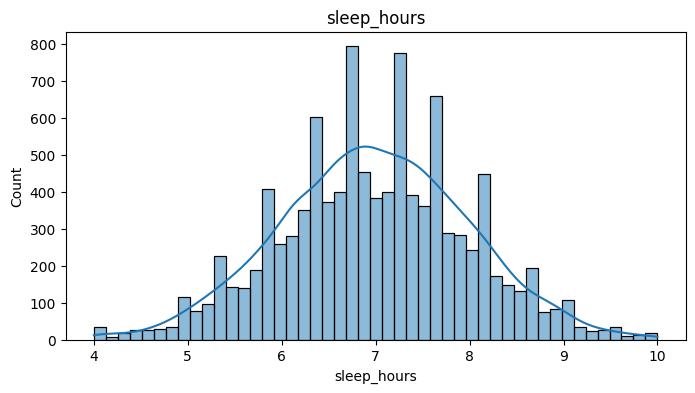

In [10]:
numeric_missing_cols = [
    "seeks_career_counseling",
    "self_learning_hours_per_week",
    "social_media_hrs_per_day",
    "sleep_hours"
]

for col in numeric_missing_cols:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df_train,
        x=col,
        kde=True
    )

    plt.title(col)
    plt.show()

## 8. Exploratory Data Analysis — Numerical Features vs. Target

All numeric features are plotted as grouped histograms split by the binary target `seeks_career_counseling` (0 = No, 1 = Yes). This reveals which features exhibit visibly different distributions across the two classes — a quick proxy for predictive relevance before formal feature selection.

In [11]:
df_train.columns

Index(['student_id', 'age', 'gender', 'degree_type', 'stream', 'year_of_study',
       'college_tier', 'urban_or_rural', 'daily_ai_tool_usage_hrs',
       'primary_ai_tools_used', 'uses_ai_for_assignments',
       'ai_replaces_own_thinking_score', 'ai_dependency_score',
       'placement_anxiety_score', 'fear_of_job_loss_to_ai',
       'career_clarity_score', 'internship_experience',
       'weekly_job_application_count', 'resume_confidence_score',
       'interview_anxiety_score', 'daily_study_hours',
       'self_learning_hours_per_week', 'skill_development_courses_taken',
       'social_media_hrs_per_day', 'sleep_hours', 'stress_level',
       'burnout_score', 'motivation_score', 'seeks_career_counseling',
       'overall_career_readiness_score'],
      dtype='object')

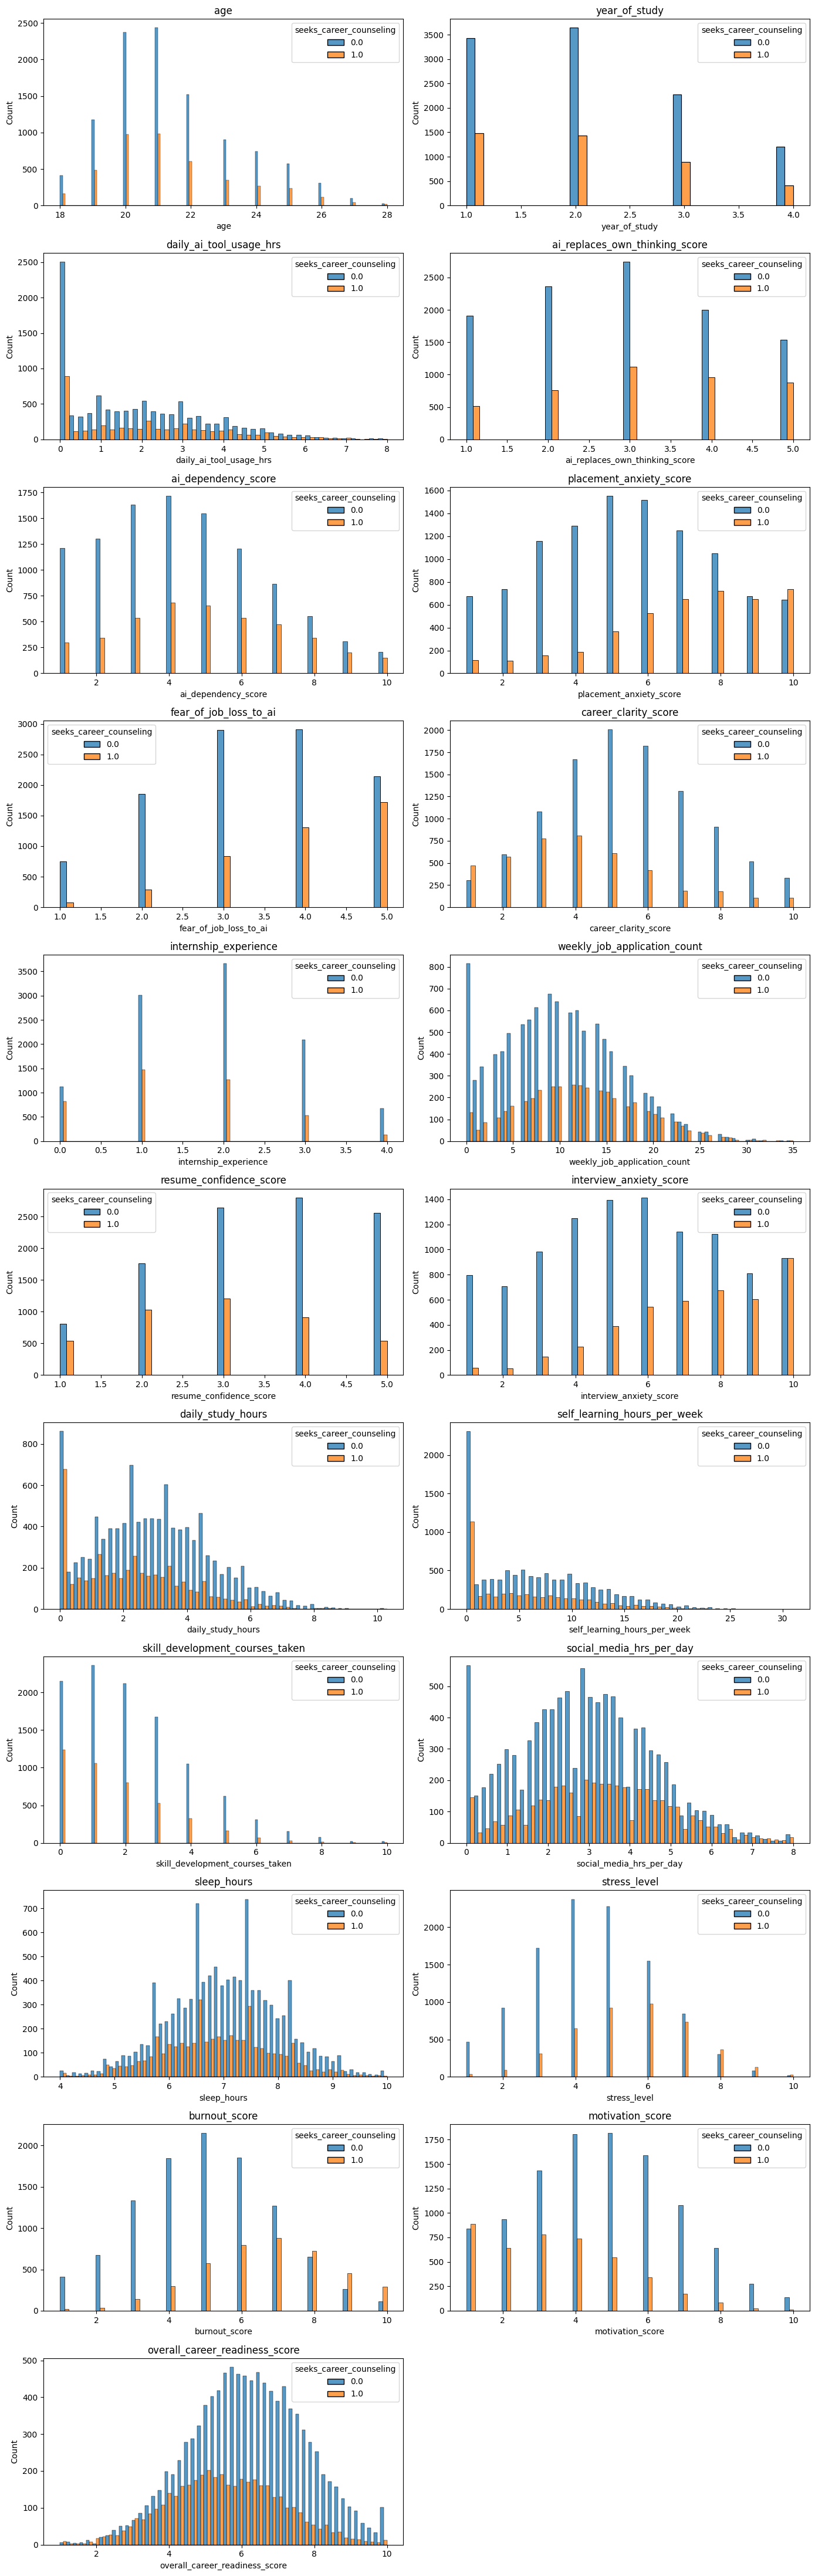

In [12]:
cols = df.select_dtypes(include='number').columns.drop('seeks_career_counseling', errors='ignore')

n = len(cols)
rows = (n + 1) // 2

fig, ax = plt.subplots(rows, 2, figsize=(14, 4 * rows))
ax = ax.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, hue='seeks_career_counseling', ax=ax[i], multiple='dodge')
    ax[i].set_title(col)

for i in range(len(cols), len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout()

## 9. Numeric Imputation — Median Fill

Versioned copies (`df_train1`, `df_test1`) are created before any in-place changes, preserving the originals for reference.

Median values are computed **only on the training set** and applied to both train and test. This is the correct approach — computing the median on the test set would constitute data leakage.

`seeks_career_counseling` is binary (0/1) and its mode — also derived from training data — is used for imputation.

In [13]:
df_train1 = df_train.copy()
df_test1 = df_test.copy()

numeric_cols = [
    'sleep_hours',
    'social_media_hrs_per_day',
    'self_learning_hours_per_week'
]

for col in numeric_cols:
    median_value = df_train1[col].median()

    df_train1[col] = df_train1[col].fillna(median_value)
    df_test1[col] = df_test1[col].fillna(median_value)

In [14]:
train_mode = df_train1['seeks_career_counseling'].mode()[0]

df_train1['seeks_career_counseling'] = (
    df_train1['seeks_career_counseling'].fillna(train_mode)
)
df_test1['seeks_career_counseling'] = (
    df_test1['seeks_career_counseling'].fillna(train_mode)
)

## 10. Categorical Column Inspection

All object/category columns are printed with their unique values and value counts. This step exposes:
- Unexpected strings or typos before encoding
- Class imbalance in categorical features
- Whether ordinal or nominal encoding is appropriate for each column

In [15]:
categorical_df = df_train1.select_dtypes(include=['object', 'category'])

for col in categorical_df.columns:
    print(f"{col}: {categorical_df[col].unique()}\n")
    print(f"{col}:\n{categorical_df[col].value_counts()}\n")

student_id: ['STU_00692' 'STU_00993' 'STU_14361' ... 'STU_13286' 'STU_05553'
 'STU_11844']

student_id:
student_id
STU_11844    1
STU_00692    1
STU_00993    1
STU_14361    1
STU_11767    1
            ..
STU_00811    1
STU_13247    1
STU_12558    1
STU_09744    1
STU_11499    1
Name: count, Length: 10500, dtype: int64

gender: ['Female' 'Male' 'Non-binary']

gender:
gender
Male          5470
Female        4731
Non-binary     299
Name: count, dtype: int64

degree_type: ['M.Tech/M.Sc' 'B.Tech/B.E.' 'B.Sc/B.A/B.Com' 'MBA']

degree_type:
degree_type
B.Tech/B.E.       4681
B.Sc/B.A/B.Com    3164
M.Tech/M.Sc       1596
MBA               1059
Name: count, dtype: int64

stream: ['Engineering (Non-CS)' 'Commerce/Management' 'CS/IT' 'Arts/Sciences']

stream:
stream
CS/IT                   4311
Engineering (Non-CS)    2620
Commerce/Management     2048
Arts/Sciences           1521
Name: count, dtype: int64

college_tier: ['Tier 3' 'Tier 2' 'Tier 1']

college_tier:
college_tier
Tier 3    5201
Tier

## 11. Feature Engineering & Encoding

Fresh versioned copies (`df_train2`, `df_test2`) are created for all encoding work.

**`student_id`** is dropped — it is an arbitrary identifier with no predictive value.

**Ordinal encoding** is applied to columns whose categories have a natural rank order:

| Column | Mapping |
|--------|---------|
| `college_tier` | Tier 3 → 0, Tier 2 → 1, Tier 1 → 2 |
| `uses_ai_for_assignments` | Never → 0 … Always → 4 |
| `urban_or_rural` | Rural → 0, Urban → 1 |

**One-hot encoding** (`pd.get_dummies` with `drop_first=True`) is applied to nominal columns with no natural ordering:
- `gender`, `degree_type`, `stream`, `primary_ai_tools_used`

`drop_first=True` removes one dummy per group to avoid perfect multicollinearity (the dummy variable trap).

**`df_train2.align(df_test2, join='left')`** ensures that if the test set is missing any dummy category that appeared in training, the corresponding column is added and filled with 0. This prevents shape mismatch errors during inference.

In [16]:
df_train2 = df_train1.copy()
df_test2 = df_test1.copy()

df_train2.drop('student_id', axis=1, inplace=True)
df_test2.drop('student_id', axis=1, inplace=True)

college_tier_map = {
    'Tier 3': 0,
    'Tier 2': 1,
    'Tier 1': 2
}
df_train2['college_tier'] = df_train2['college_tier'].map(college_tier_map)
df_test2['college_tier'] = df_test2['college_tier'].map(college_tier_map)

assignment_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Frequently': 3,
    'Always': 4
}
df_train2['uses_ai_for_assignments'] = df_train2['uses_ai_for_assignments'].map(assignment_map)
df_test2['uses_ai_for_assignments'] = df_test2['uses_ai_for_assignments'].map(assignment_map)

urban_rural_map = {
    'Urban': 1,
    'Rural': 0
}
df_train2['urban_or_rural'] = df_train2['urban_or_rural'].map(urban_rural_map)
df_test2['urban_or_rural'] = df_test2['urban_or_rural'].map(urban_rural_map)

categorical_cols = [
    'gender',
    'degree_type',
    'stream',
    'primary_ai_tools_used'
]
df_train2 = pd.get_dummies(df_train2, columns=categorical_cols, drop_first=True)
df_test2 = pd.get_dummies(df_test2, columns=categorical_cols, drop_first=True)

df_train2, df_test2 = df_train2.align(df_test2, join='left', axis=1, fill_value=0)

print(df_train2.shape)
print(df_test2.shape)
df_train2.head()

(10500, 39)
(4500, 39)


,age,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,uses_ai_for_assignments,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,...,degree_type_MBA,stream_CS/IT,stream_Commerce/Management,stream_Engineering (Non-CS),primary_ai_tools_used_Claude,primary_ai_tools_used_Gemini,primary_ai_tools_used_GitHub Copilot,primary_ai_tools_used_None,primary_ai_tools_used_Perplexity,primary_ai_tools_used_Unknown
691,24,2,0,0,0.0,0,1,4,4,3,...,False,False,False,True,False,False,False,True,False,False
992,20,2,0,0,2.0,1,3,3,5,4,...,False,False,False,True,False,False,False,False,False,False
14360,20,2,0,0,3.7,2,4,3,7,5,...,False,False,True,False,True,False,False,False,False,False
14092,24,1,0,1,0.0,0,5,5,8,2,...,False,False,True,False,False,False,False,True,False,False
4056,20,3,1,1,2.0,1,2,4,10,5,...,False,True,False,False,False,True,False,False,False,False


In [17]:
df_train2.describe()

,age,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,uses_ai_for_assignments,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
count,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,...,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000
mean,21.382857,2.105048,0.652571,0.684571,2.038629,1.342667,3.001524,4.564286,5.902381,3.547524,...,2.725943,6.281933,2.029810,3.019971,6.982314,4.762857,5.491429,4.311810,0.281714,5.995040
std,2.004161,0.985809,0.722898,0.464708,1.742055,1.172155,1.313436,2.327865,2.546135,1.179858,...,1.801930,5.520862,1.809997,1.642727,0.999959,1.780066,2.062557,2.138974,0.449856,1.587927
min,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,1.000000,0.000000,0.000000,0.400000,0.000000,2.000000,3.000000,4.000000,3.000000,...,1.300000,1.100000,1.000000,1.900000,6.300000,4.000000,4.000000,3.000000,0.000000,4.900000
50%,21.000000,2.000000,1.000000,1.000000,1.800000,1.000000,3.000000,4.000000,6.000000,4.000000,...,2.600000,5.400000,2.000000,3.000000,7.000000,5.000000,5.000000,4.000000,0.000000,5.990000
75%,22.000000,3.000000,1.000000,1.000000,3.200000,2.000000,4.000000,6.000000,8.000000,5.000000,...,4.000000,10.000000,3.000000,4.200000,7.700000,6.000000,7.000000,6.000000,1.000000,7.110000
max,28.000000,4.000000,2.000000,1.000000,8.000000,4.000000,5.000000,10.000000,10.000000,5.000000,...,10.300000,31.000000,10.000000,8.000000,10.000000,10.000000,10.000000,10.000000,1.000000,10.000000


## 12. Column Classification

Columns are explicitly partitioned into **numerical** and **categorical** lists. This classification is used downstream to direct the correct visualisation and scaling logic to the right features.

In [18]:
numerical_cols = [
    'age',
    'year_of_study',
    'daily_ai_tool_usage_hrs',
    'ai_replaces_own_thinking_score',
    'ai_dependency_score',
    'placement_anxiety_score',
    'fear_of_job_loss_to_ai',
    'career_clarity_score',
    'weekly_job_application_count',
    'resume_confidence_score',
    'interview_anxiety_score',
    'daily_study_hours',
    'self_learning_hours_per_week',
    'skill_development_courses_taken',
    'social_media_hrs_per_day',
    'sleep_hours',
    'stress_level',
    'burnout_score',
    'motivation_score',
    'overall_career_readiness_score'
]

categorical_cols = [
    'college_tier',
    'urban_or_rural',
    'uses_ai_for_assignments',
    'internship_experience',
    'seeks_career_counseling',

    'gender_Male',
    'gender_Non-binary',

    'degree_type_B.Tech/B.E.',
    'degree_type_M.Tech/M.Sc',
    'degree_type_MBA',

    'stream_CS/IT',
    'stream_Commerce/Management',
    'stream_Engineering (Non-CS)',

    'primary_ai_tools_used_Claude',
    'primary_ai_tools_used_Gemini',
    'primary_ai_tools_used_GitHub Copilot',
    'primary_ai_tools_used_None',
    'primary_ai_tools_used_Perplexity',
    'primary_ai_tools_used_Unknown'
]

## 13. Distribution Analysis — KDE Plots

Kernel Density Estimation plots are generated for all numerical columns in a 3-column grid. KDE provides a smoothed continuous estimate of the probability density, making it easier to spot skewness, bimodality, or floor/ceiling effects that plain histograms can obscure.

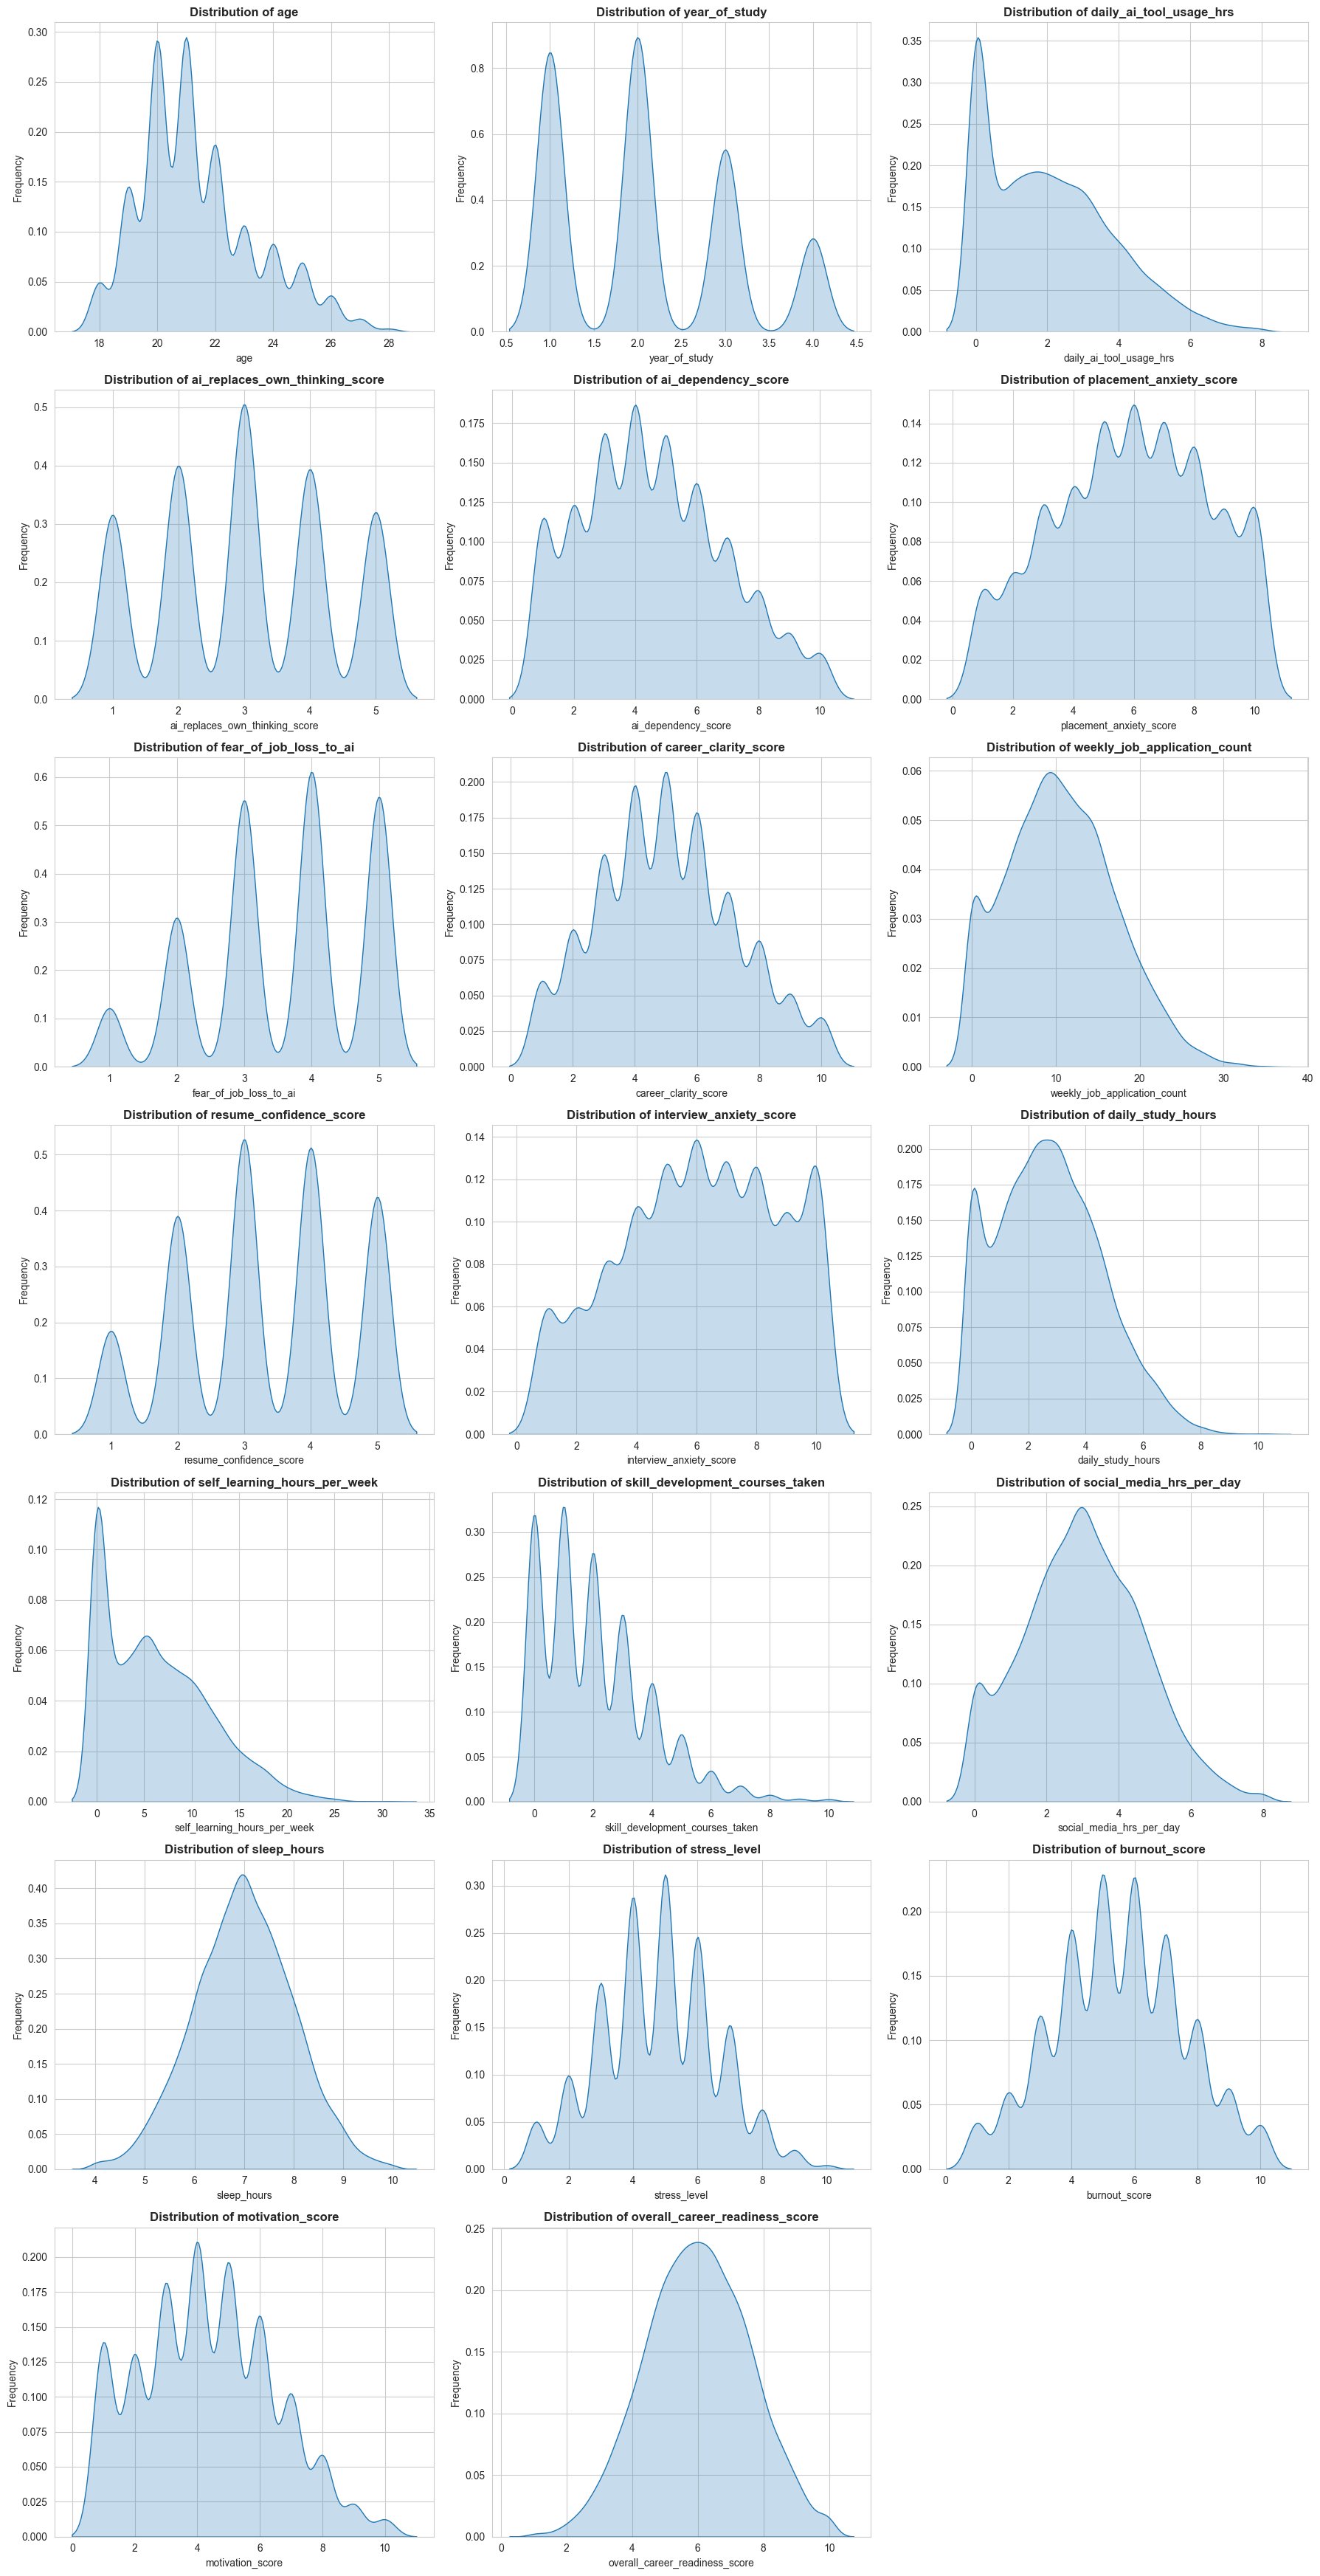

In [19]:
sns.set_style("whitegrid")
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.kdeplot(data=df_train2, x=col, fill=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 14. Correlation Heatmap

A Pearson correlation matrix is computed for all numerical features and visualised as an annotated heatmap. Values close to +1 or -1 indicate strong linear relationships — relevant both for understanding the data and for identifying multicollinearity before modelling.

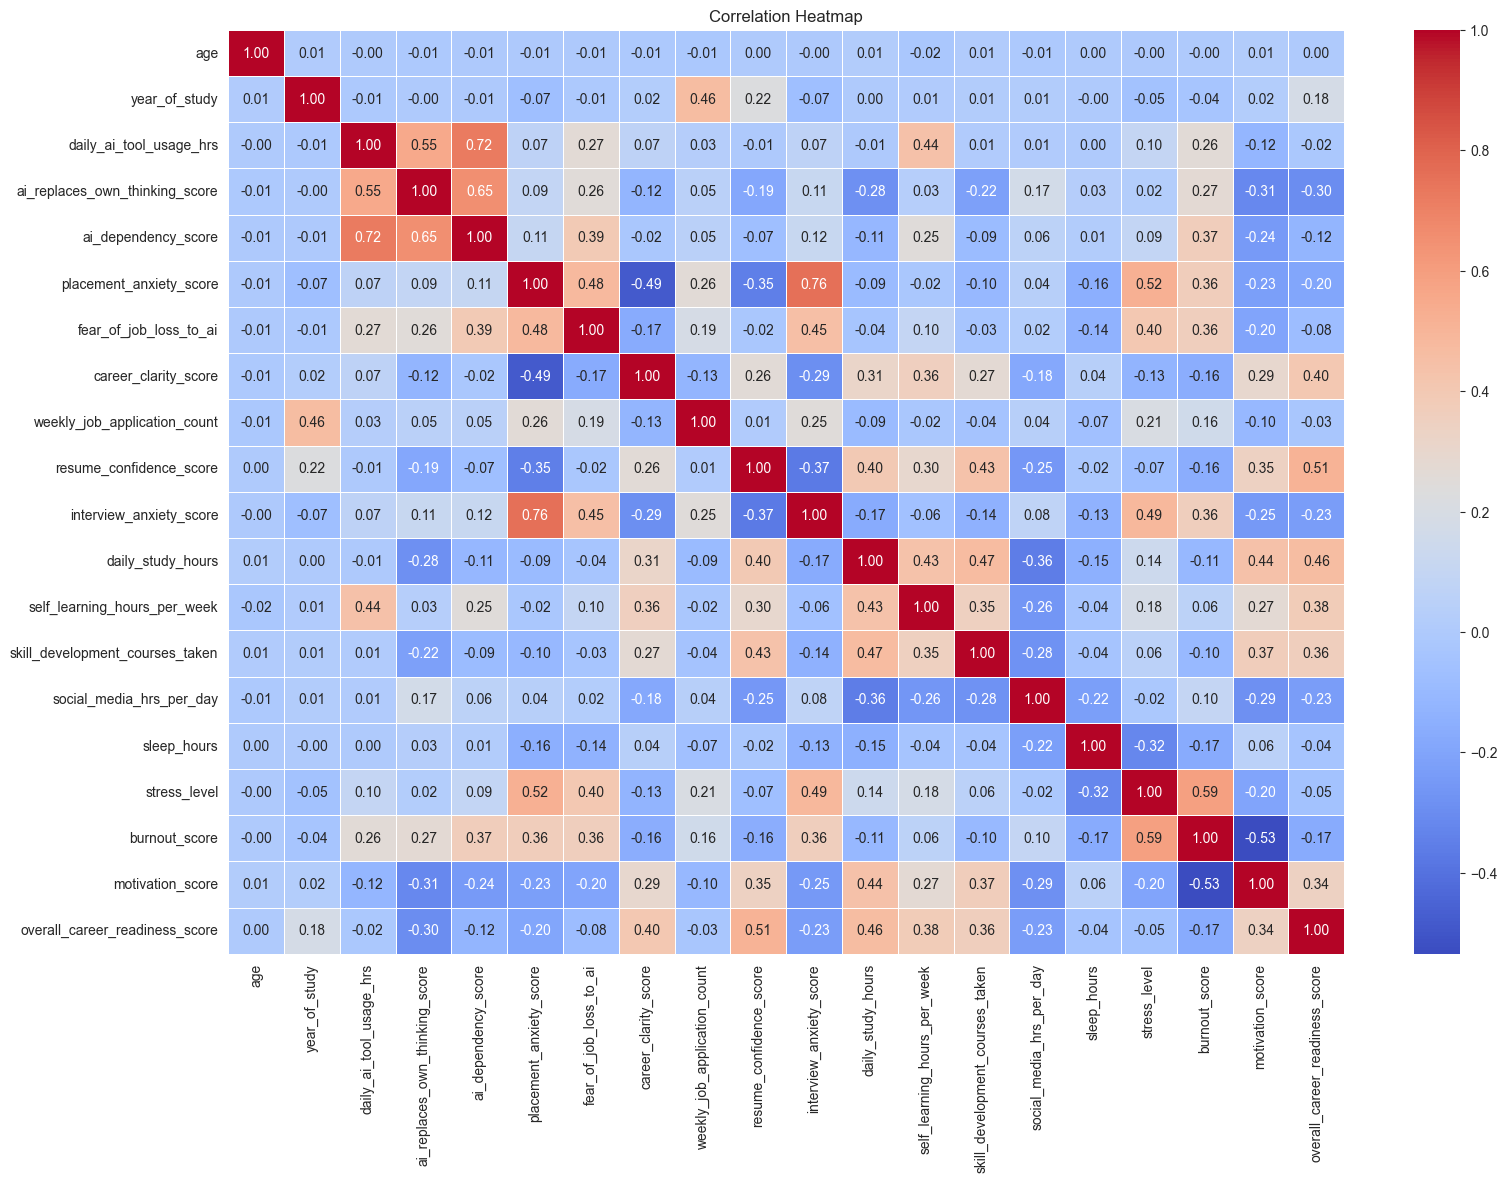

In [20]:
corr_matrix = df_train2[numerical_cols].corr()

plt.figure(figsize=(18, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

## 15. Target Separation & Feature Matrix Construction

Three prediction targets are extracted from the encoded dataframes. All three are dropped from the feature matrix (`X_train`, `X_test`) to prevent target leakage:

| Variable | Target |
|----------|--------|
| `y_train1` / `y_test1` | `burnout_score` (regression) |
| `y_train2` / `y_test2` | `seeks_career_counseling` (binary classification) |
| `y_train3` / `y_test3` | `overall_career_readiness_score` (regression) |

In [21]:
X_train = df_train2.drop(['burnout_score', 'seeks_career_counseling', 'overall_career_readiness_score'], axis=1)
X_test = df_test2.drop(['burnout_score', 'seeks_career_counseling', 'overall_career_readiness_score'], axis=1)

y_train1 = df_train2['burnout_score']
y_test1 = df_test2['burnout_score']

y_train2 = df_train2['seeks_career_counseling']
y_test2 = df_test2['seeks_career_counseling']

y_train3 = df_train2['overall_career_readiness_score']
y_test3 = df_test2['overall_career_readiness_score']

## 16. Feature Scaling — MinMax Normalisation

`MinMaxScaler` transforms each numeric feature to the [0, 1] range. This is required for distance-sensitive and regularised models (e.g. Lasso, ElasticNet, Logistic Regression).

- `.fit_transform()` is called **only on the training set** — the scaler learns its min/max from training data.
- `.transform()` is applied to the test set using those same training statistics. Fitting the scaler on the test set would again constitute data leakage.

Only numeric (int64/float64) columns are scaled; binary dummy columns remain unchanged.

In [22]:
scaler = MinMaxScaler()
cols_to_scale = X_train.select_dtypes(include=["int64", "float64"]).columns

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

## 17. Multicollinearity Check — Variance Inflation Factor (VIF)

VIF quantifies how much the variance of a regression coefficient is inflated due to linear dependence with other features.

- **VIF < 5**: Low multicollinearity — acceptable.
- **VIF 5–10**: Moderate — worth investigating.
- **VIF > 10**: High multicollinearity — the feature adds little unique information and can destabilise coefficient estimates.

The helper function `calculate_vif` wraps `statsmodels.variance_inflation_factor` and returns a clean two-column DataFrame for inspection.

In [23]:
def calculate_vif(data):
    """Compute Variance Inflation Factor for all columns in a numeric DataFrame.

    Parameters
    ----------
    data : pd.DataFrame
        DataFrame containing only numeric features (no categorical columns).

    Returns
    -------
    pd.DataFrame
        Two-column table with 'Variable' and 'VIF' for each input feature.
        VIF > 10 indicates high multicollinearity; these features should be dropped.
    """
    vif_df = pd.DataFrame()
    vif_df['Variable'] = data.columns
    vif_df['VIF'] = [
        variance_inflation_factor(data.values, i)
        for i in range(data.shape[1])
    ]
    return vif_df

In [24]:
calculate_vif(X_train[cols_to_scale])

,Variable,VIF
0,age,3.709580
1,year_of_study,3.990427
2,college_tier,2.938360
3,urban_or_rural,3.092833
4,daily_ai_tool_usage_hrs,48.420796
5,uses_ai_for_assignments,43.870735
6,ai_replaces_own_thinking_score,6.669062
7,ai_dependency_score,9.563211
8,placement_anxiety_score,16.084680
9,fear_of_job_loss_to_ai,9.893630


### VIF — After Removing High-VIF Features

`uses_ai_for_assignments` and `placement_anxiety_score` are identified as high-VIF features. VIF is recalculated after their removal to confirm that multicollinearity has been resolved.

In [25]:
calculate_vif(X_train[cols_to_scale].drop(['uses_ai_for_assignments', 'placement_anxiety_score'], axis=1))

,Variable,VIF
0,age,3.701436
1,year_of_study,3.979112
2,college_tier,2.930019
3,urban_or_rural,3.086872
4,daily_ai_tool_usage_hrs,6.228021
5,ai_replaces_own_thinking_score,6.664160
6,ai_dependency_score,9.551003
7,fear_of_job_loss_to_ai,9.358685
8,career_clarity_score,5.384026
9,internship_experience,9.049852


In [26]:
X_train1 = X_train.copy()
X_test1 = X_test.copy()

X_train1.drop(['uses_ai_for_assignments', 'placement_anxiety_score'], axis=1, inplace=True)
X_test1.drop(['uses_ai_for_assignments', 'placement_anxiety_score'], axis=1, inplace=True)

In [27]:
X_train1.columns

Index(['age', 'year_of_study', 'college_tier', 'urban_or_rural',
       'daily_ai_tool_usage_hrs', 'ai_replaces_own_thinking_score',
       'ai_dependency_score', 'fear_of_job_loss_to_ai', 'career_clarity_score',
       'internship_experience', 'weekly_job_application_count',
       'resume_confidence_score', 'interview_anxiety_score',
       'daily_study_hours', 'self_learning_hours_per_week',
       'skill_development_courses_taken', 'social_media_hrs_per_day',
       'sleep_hours', 'stress_level', 'motivation_score', 'gender_Male',
       'gender_Non-binary', 'degree_type_B.Tech/B.E.',
       'degree_type_M.Tech/M.Sc', 'degree_type_MBA', 'stream_CS/IT',
       'stream_Commerce/Management', 'stream_Engineering (Non-CS)',
       'primary_ai_tools_used_Claude', 'primary_ai_tools_used_Gemini',
       'primary_ai_tools_used_GitHub Copilot', 'primary_ai_tools_used_None',
       'primary_ai_tools_used_Perplexity', 'primary_ai_tools_used_Unknown'],
      dtype='object')

## 18. Feature Selection — Weight of Evidence & Information Value

Weight of Evidence (WoE) and Information Value (IV) are credit-scoring techniques repurposed here for **binary classification feature selection** (target: `seeks_career_counseling`).

**WoE per bin** = ln(Distribution of Events / Distribution of Non-Events)

**IV** = Σ (Distribution of Events − Distribution of Non-Events) × WoE

IV thresholds used:

| IV Range | Predictive Power |
|----------|-----------------|
| < 0.02 | Negligible — dropped |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| > 0.3 | Strong |

Continuous features are **binned into deciles** (`pd.qcut` with `q=10`) before IV computation. Features with infinite IV (caused by a bin containing zero events or non-events) are treated as uninformative and set to 0.

Only features with **IV > 0.02** are retained in `best_columns`.

In [28]:
def calculate_woe_iv(df, feature, target):
    """Compute Weight of Evidence (WoE) and Information Value (IV) for a feature.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the feature and target columns.
    feature : str or pd.Series
        Column name (for categoricals) or a pre-binned Series (for continuous features).
    target : str
        Name of the binary target column (1 = event, 0 = non-event).

    Returns
    -------
    woe : pd.Series
        WoE value for each category/bin.
    iv : float
        Total Information Value for the feature.

    Notes
    -----
    WoE = ln(Distribution of Events / Distribution of Non-Events) per bin.
    IV  = sum over bins of (Dist Events - Dist Non-Events) * WoE.
    """
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped['non_default'] = grouped['count'] - grouped['sum']
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'default'})

    grouped['approve_ratio']     = grouped['default']     / grouped['default'].sum()
    grouped['non_approve_ratio'] = grouped['non_default'] / grouped['non_default'].sum()

    grouped['woe'] = np.log(grouped['approve_ratio'] / grouped['non_approve_ratio'])
    grouped['iv']  = (grouped['approve_ratio'] - grouped['non_approve_ratio']) * grouped['woe']

    return grouped['woe'], grouped['iv'].sum()

In [29]:
df_temp = pd.concat([X_train1, y_train2], axis=1)

best_columns = []
iv_results = []

for i in X_train1.columns:

    temp = df_temp.copy()

    if X_train1[i].dtype == 'object':
        woe, iv = calculate_woe_iv(temp, i, 'seeks_career_counseling')

    else:
        temp[f'{i}_bin'] = pd.qcut(X_train1[i], q=10, duplicates='drop')
        woe, iv = calculate_woe_iv(temp, f'{i}_bin', 'seeks_career_counseling')

    if np.isinf(iv):
        iv = 0

    iv_results.append([i, iv])

    if iv > 0.02:
        best_columns.append(i)

    print(f"\nFeature : {i}")
    print(f"IV      : {iv:.4f} {'✓ Selected' if iv > 0.02 else '✗ Dropped'}")
    print("WoE per bin/category:")
    print(woe)
    print("-" * 50)

iv_df = pd.DataFrame(iv_results, columns=['Feature', 'IV']).sort_values('IV', ascending=False)

print("\nIV Ranking")
print(iv_df)

print("\nSelected Features")
print(best_columns)

C:\Users\soham\AppData\Local\Temp\ipykernel_19720\127465899.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])
C:\Users\soham\AppData\Local\Temp\ipykernel_19720\127465899.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])
C:\Users\soham\AppData\Local\Temp\ipykernel_19720\127465899.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future d


Feature : age
IV      : 0.0033 ✗ Dropped
WoE per bin/category:
age_bin
(-0.001, 0.1]   -0.016393
(0.1, 0.2]       0.024945
(0.2, 0.3]       0.074433
(0.3, 0.4]      -0.058980
(0.4, 0.5]      -0.041686
(0.5, 0.6]      -0.131357
(0.6, 1.0]      -0.000119
Name: woe, dtype: float64
--------------------------------------------------

Feature : year_of_study
IV      : 0.0045 ✗ Dropped
WoE per bin/category:
year_of_study_bin
(-0.001, 0.333]    0.034044
(0.333, 0.667]    -0.016343
(0.667, 1.0]      -0.187072
Name: woe, dtype: float64
--------------------------------------------------

Feature : college_tier
IV      : 0.0434 ✓ Selected
WoE per bin/category:
college_tier_bin
(-0.001, 0.5]    0.080626
(0.5, 1.0]      -0.539636
Name: woe, dtype: float64
--------------------------------------------------

Feature : urban_or_rural
IV      : 0.0000 ✗ Dropped
WoE per bin/category:
urban_or_rural_bin
(-0.001, 1.0]    0.0
Name: woe, dtype: float64
--------------------------------------------------

Fea

C:\Users\soham\AppData\Local\Temp\ipykernel_19720\127465899.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])
C:\Users\soham\AppData\Local\Temp\ipykernel_19720\127465899.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])
C:\Users\soham\AppData\Local\Temp\ipykernel_19720\127465899.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future d

In [30]:
X_train2 = X_train1[best_columns]
X_test2 = X_test1[best_columns]

## 19. Target 1 — `burnout_score` (Regression)

### 19.1 Baseline Models

Three baseline regressors are trained without tuning to establish benchmark performance:
- **Linear Regression** — assumes a linear relationship; interpretable but limited.
- **Random Forest Regressor** — non-parametric ensemble; captures non-linearity.
- **XGBoost Regressor** — gradient-boosted trees; typically the strongest out-of-the-box.

Metrics reported: MAE, MSE, RMSE, R².

In [31]:
model_lr1 = LinearRegression()
model_lr1.fit(X_train1, y_train1)
y_pred = model_lr1.predict(X_test1)

print(f"MAE  : {mean_absolute_error(y_test1, y_pred)}")
print(f"MSE  : {mean_squared_error(y_test1, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test1, y_pred))}")
print(f"R2   : {r2_score(y_test1, y_pred)}")

MAE  : 1.0989379927436658
MSE  : 1.890012254944428
RMSE : 1.3747771655597236
R2   : 0.5635770406348486


In [32]:
model_rf1 = RandomForestRegressor()
model_rf1.fit(X_train1, y_train1)
y_pred = model_rf1.predict(X_test1)

print(f"MAE  : {mean_absolute_error(y_test1, y_pred)}")
print(f"MSE  : {mean_squared_error(y_test1, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test1, y_pred))}")
print(f"R2   : {r2_score(y_test1, y_pred)}")

MAE  : 1.1463533333333333
MSE  : 2.0464907333333335
RMSE : 1.4305560923407838
R2   : 0.5274445761829448


In [33]:
model_xgb = XGBRegressor()
model_xgb.fit(X_train1, y_train1)
y_pred = model_xgb.predict(X_test1)

print(f"MAE  : {mean_absolute_error(y_test1, y_pred)}")
print(f"MSE  : {mean_squared_error(y_test1, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test1, y_pred))}")
print(f"R2   : {r2_score(y_test1, y_pred)}")

MAE  : 1.1754837036132812
MSE  : 2.160311222076416
RMSE : 1.4697997217568168
R2   : 0.5011622905731201


### 19.2 Linear Model Hyperparameter Search (Optuna)

An Optuna study searches across four linear model types — OLS, Ridge, Lasso, and ElasticNet — selecting the best regularisation penalty and strength via 5-fold cross-validated R². The TPE (Tree-structured Parzen Estimator) sampler is used with a fixed seed for reproducibility.

In [34]:
def objective_linear(trial):

    model_type = trial.suggest_categorical(
        "model_type",
        ["linear", "ridge", "lasso", "elasticnet"]
    )

    if model_type == "linear":
        model = LinearRegression()

    elif model_type == "ridge":
        model = Ridge(
            alpha=trial.suggest_float("alpha", 1e-5, 100, log=True)
        )

    elif model_type == "lasso":
        model = Lasso(
            alpha=trial.suggest_float("alpha", 1e-5, 10, log=True),
            max_iter=10000
        )

    else:
        model = ElasticNet(
            alpha=trial.suggest_float("alpha", 1e-5, 10, log=True),
            l1_ratio=trial.suggest_float("l1_ratio", 0.01, 0.99),
            max_iter=10000
        )

    score = cross_val_score(
        model, X_train1, y_train1, cv=5, scoring="r2", n_jobs=-1
    ).mean()

    return score


study_linear = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_linear.optimize(objective_linear, n_trials=50)

print("Best CV R2:", study_linear.best_value)
print("Best Parameters:", study_linear.best_params)

[I 2026-06-15 12:56:40,502] A new study created in memory with name: no-name-ee8b27e7-6db4-40ac-b6f5-8cf741c03a22
[I 2026-06-15 12:56:43,983] Trial 0 finished with value: 0.5770743287696133 and parameters: {'model_type': 'ridge', 'alpha': 0.000123631882770522}. Best is trial 0 with value: 0.5770743287696133.
[I 2026-06-15 12:56:47,100] Trial 1 finished with value: 0.2596351467688087 and parameters: {'model_type': 'lasso', 'alpha': 0.1771884735480681}. Best is trial 0 with value: 0.5770743287696133.
[I 2026-06-15 12:56:50,121] Trial 2 finished with value: 0.5770743294416707 and parameters: {'model_type': 'ridge', 'alpha': 0.00018740223688836313}. Best is trial 2 with value: 0.5770743294416707.
[I 2026-06-15 12:56:52,828] Trial 3 finished with value: 0.5772374337763921 and parameters: {'model_type': 'lasso', 'alpha': 0.000558952420521792}. Best is trial 3 with value: 0.5772374337763921.
[I 2026-06-15 12:56:53,012] Trial 4 finished with value: 0.5770743274665786 and parameters: {'model_ty

Best CV R2: 0.5776346476023232
Best Parameters: {'model_type': 'lasso', 'alpha': 0.0037304113621354474}


### 19.3 Best Linear Model — Test Set Evaluation

In [35]:
best_params = study_linear.best_params.copy()
best_params.pop('model_type', None)

model_1_best_en = Lasso(**best_params)
model_1_best_en.fit(X_train1, y_train1)
y_pred = model_1_best_en.predict(X_test1)

print(f"MAE  : {mean_absolute_error(y_test1, y_pred)}")
print(f"MSE  : {mean_squared_error(y_test1, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test1, y_pred))}")
print(f"R2   : {r2_score(y_test1, y_pred)}")

MAE  : 1.098237805563451
MSE  : 1.888524321248063
RMSE : 1.3742359045113262
R2   : 0.5639206195854125


### 19.4 XGBoost Hyperparameter Search (Optuna)

A broader search over XGBoost-specific parameters is conducted with 100 trials and 3-fold CV. The `MedianPruner` terminates unpromising trials early based on intermediate cross-validation scores, reducing total compute time.

Key search dimensions include tree depth, learning rate, subsampling ratios, L1/L2 regularisation, and growth policy.

In [36]:
def objective_xgb(trial):

    params = {
        "objective": "reg:squarederror",
        "random_state": 42,
        "tree_method": "hist",
        "n_jobs": -1,

        "n_estimators": trial.suggest_int("n_estimators", 100, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 15),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 100, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 100, log=True),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])
    }

    model = XGBRegressor(**params)

    score = cross_val_score(
        model, X_train1, y_train1, cv=3, scoring="r2", n_jobs=-1
    ).mean()

    return score


study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

print(study_xgb.best_value)
print(study_xgb.best_params)

[I 2026-06-15 12:57:02,936] A new study created in memory with name: no-name-16d15c3a-af60-43a6-ad25-05a592c6c485
Best trial: 0. Best value: 0.452122:   1%|▍                                            | 1/100 [00:01<02:18,  1.40s/it]

[I 2026-06-15 12:57:04,335] Trial 0 finished with value: 0.4521216154098511 and parameters: {'n_estimators': 624, 'learning_rate': 0.22648248189516848, 'max_depth': 12, 'min_child_weight': 12, 'gamma': 1.5601864044243652, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'colsample_bylevel': 0.9330880728874675, 'colsample_bynode': 0.8005575058716043, 'reg_alpha': 0.12042752972516801, 'reg_lambda': 1.6063676259174453e-08, 'max_delta_step': 10, 'grow_policy': 'depthwise'}. Best is trial 0 with value: 0.4521216154098511.


Best trial: 0. Best value: 0.452122:   2%|▉                                            | 2/100 [00:02<02:18,  1.41s/it]

[I 2026-06-15 12:57:05,762] Trial 1 finished with value: 0.43365079164505005 and parameters: {'n_estimators': 354, 'learning_rate': 0.002846526357761094, 'max_depth': 6, 'min_child_weight': 11, 'gamma': 4.319450186421157, 'subsample': 0.645614570099021, 'colsample_bytree': 0.8059264473611898, 'colsample_bylevel': 0.569746930326021, 'colsample_bynode': 0.6460723242676091, 'reg_alpha': 4.609124432595992e-05, 'reg_lambda': 0.0003636636071695854, 'max_delta_step': 8, 'grow_policy': 'lossguide'}. Best is trial 0 with value: 0.4521216154098511.


Best trial: 2. Best value: 0.505134:   3%|█▎                                           | 3/100 [00:17<11:59,  7.42s/it]

...

[I 2026-06-15 12:59:32,774] Trial 97 finished with value: 0.5748004714647929 and parameters: {'n_estimators': 1165, 'learning_rate': 0.009398980058517331, 'max_depth': 2, 'min_child_weight': 2, 'gamma': 8.944184206766465, 'subsample': 0.9415900943760804, 'colsample_bytree': 0.7557724458888911, 'colsample_bylevel': 0.9522535058765833, 'colsample_bynode': 0.9376446795029646, 'reg_alpha': 6.85661976855269e-08, 'reg_lambda': 0.9626622779986057, 'max_delta_step': 0, 'grow_policy': 'depthwise'}. Best is trial 84 with value: 0.5750763217608134.


Best trial: 84. Best value: 0.575076:  99%|██████████████████████████████████████████▌| 99/100 [02:32<00:01,  1.92s/it]

[I 2026-06-15 12:59:34,961] Trial 98 finished with value: 0.5737925171852112 and parameters: {'n_estimators': 1179, 'learning_rate': 0.006193196013262822, 'max_depth': 3, 'min_child_weight': 2, 'gamma': 8.868272929687555, 'subsample': 0.9634188441872907, 'colsample_bytree': 0.8091561504360492, 'colsample_bylevel': 0.9444999281719133, 'colsample_bynode': 0.9349455955501438, 'reg_alpha': 3.3022316920089743e-07, 'reg_lambda': 1.1173923582845853, 'max_delta_step': 3, 'grow_policy': 'depthwise'}. Best is trial 84 with value: 0.5750763217608134.


Best trial: 84. Best value: 0.575076: 100%|██████████████████████████████████████████| 100/100 [02:33<00:00,  1.54s/it]

[I 2026-06-15 12:59:36,678] Trial 99 finished with value: 0.5688593586285909 and parameters: {'n_estimators': 1095, 'learning_rate': 0.0052953569823682165, 'max_depth': 2, 'min_child_weight': 2, 'gamma': 8.16495128804676, 'subsample': 0.9876972864150793, 'colsample_bytree': 0.7475708632925532, 'colsample_bylevel': 0.9525575670891943, 'colsample_bynode': 0.9841535022951523, 'reg_alpha': 1.054392565269374e-06, 'reg_lambda': 2.6664283489671727, 'max_delta_step': 1, 'grow_policy': 'lossguide'}. Best is trial 84 with value: 0.5750763217608134.
0.5750763217608134
{'n_estimators': 1218, 'learning_rate': 0.008387530174337115, 'max_depth': 2, 'min_child_weight': 3, 'gamma': 8.580475492333754, 'subsample': 0.992636331780752, 'colsample_bytree': 0.7075589569870119, 'colsample_bylevel': 0.9884514249099092, 'colsample_bynode': 0.9565955699742984, 'reg_alpha': 6.399090905749176e-08, 'reg_lambda': 2.608463818036146, 'max_delta_step': 1, 'grow_policy': 'depthwise'}


### 19.5 Best XGBoost Regressor — Test Set Evaluation

In [37]:
best_model_1 = XGBRegressor(
    **study_xgb.best_params,
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

best_model_1.fit(X_train1, y_train1)
y_pred = best_model_1.predict(X_test1)

print(f"MAE  : {mean_absolute_error(y_test1, y_pred)}")
print(f"MSE  : {mean_squared_error(y_test1, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test1, y_pred))}")
print(f"R2   : {r2_score(y_test1, y_pred)}")

MAE  : 1.1018270254135132
MSE  : 1.8955388069152832
RMSE : 1.3767856793689
R2   : 0.5623009204864502


## 20. Target 2 — `overall_career_readiness_score` (Regression)

The same modelling sequence from Section 19 is repeated for the second regression target. Baseline models are evaluated first, followed by Optuna-tuned linear and XGBoost models.

> **Note:** `X_train1` / `X_test1` are used here (the post-VIF feature set without IV filtering, since IV filtering was designed specifically for the classification target).

In [38]:
model_lr2 = LinearRegression()
model_lr2.fit(X_train1, y_train3)
y_pred = model_lr2.predict(X_test1)

print(f"MAE  : {mean_absolute_error(y_test3, y_pred)}")
print(f"MSE  : {mean_squared_error(y_test3, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test3, y_pred))}")
print(f"R2   : {r2_score(y_test3, y_pred)}")

MAE  : 0.9158853943051225
MSE  : 1.2993778745897668
RMSE : 1.139902572411242
R2   : 0.497466811833827


In [39]:
model_rf2 = RandomForestRegressor()
model_rf2.fit(X_train1, y_train3)
y_pred = model_rf2.predict(X_test1)

print(f"MAE  : {mean_absolute_error(y_test3, y_pred)}")
print(f"MSE  : {mean_squared_error(y_test3, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test3, y_pred))}")
print(f"R2   : {r2_score(y_test3, y_pred)}")

MAE  : 0.9263768666666666
MSE  : 1.3416290121977776
RMSE : 1.158287102664006
R2   : 0.48112622354075263


In [40]:
model_xgb2 = XGBRegressor()
model_xgb2.fit(X_train1, y_train3)
y_pred = model_xgb2.predict(X_test1)

print(f"MAE  : {mean_absolute_error(y_test3, y_pred)}")
print(f"MSE  : {mean_squared_error(y_test3, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test3, y_pred))}")
print(f"R2   : {r2_score(y_test3, y_pred)}")

MAE  : 0.9663733473481071
MSE  : 1.452089538192364
RMSE : 1.2050267790353724
R2   : 0.4384057175354482


### 20.1 Linear Model Search — Career Readiness

In [41]:
def objective_linear(trial):

    model_type = trial.suggest_categorical(
        "model_type",
        ["linear", "ridge", "lasso", "elasticnet"]
    )

    if model_type == "linear":
        model = LinearRegression()

    elif model_type == "ridge":
        model = Ridge(
            alpha=trial.suggest_float("alpha", 1e-5, 100, log=True)
        )

    elif model_type == "lasso":
        model = Lasso(
            alpha=trial.suggest_float("alpha", 1e-5, 10, log=True),
            max_iter=10000
        )

    else:
        model = ElasticNet(
            alpha=trial.suggest_float("alpha", 1e-5, 10, log=True),
            l1_ratio=trial.suggest_float("l1_ratio", 0.01, 0.99),
            max_iter=10000
        )

    score = cross_val_score(
        model, X_train1, y_train3, cv=5, scoring="r2", n_jobs=-1
    ).mean()

    return score


study_linear = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_linear.optimize(objective_linear, n_trials=50)

print(study_linear.best_value)
print(study_linear.best_params)

[I 2026-06-15 12:59:50,508] A new study created in memory with name: no-name-c5c2cabe-4508-406a-a273-c7883f9e0fbc
[I 2026-06-15 12:59:50,689] Trial 0 finished with value: 0.4842278726443018 and parameters: {'model_type': 'ridge', 'alpha': 0.000123631882770522}. Best is trial 0 with value: 0.4842278726443018.
[I 2026-06-15 12:59:50,890] Trial 1 finished with value: 0.17019904395367053 and parameters: {'model_type': 'lasso', 'alpha': 0.1771884735480681}. Best is trial 0 with value: 0.4842278726443018.
[I 2026-06-15 12:59:51,079] Trial 2 finished with value: 0.48422787369361764 and parameters: {'model_type': 'ridge', 'alpha': 0.00018740223688836313}. Best is trial 2 with value: 0.48422787369361764.
[I 2026-06-15 12:59:51,284] Trial 3 finished with value: 0.48471272598482396 and parameters: {'model_type': 'lasso', 'alpha': 0.000558952420521792}. Best is trial 3 with value: 0.48471272598482396.
[I 2026-06-15 12:59:51,471] Trial 4 finished with value: 0.4842278706099606 and parameters: {'mod

0.4851530474565552
{'model_type': 'elasticnet', 'alpha': 0.0021630705396345103, 'l1_ratio': 0.9860962011124865}


In [42]:
best_params = study_linear.best_params
best_params.pop('model_type', None)

model_2_best_opt_lr = ElasticNet(**best_params)
model_2_best_opt_lr.fit(X_train1, y_train3)
y_pred = model_2_best_opt_lr.predict(X_test1)

print(f"MAE  : {mean_absolute_error(y_test3, y_pred)}")
print(f"MSE  : {mean_squared_error(y_test3, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test3, y_pred))}")
print(f"R2   : {r2_score(y_test3, y_pred)}")

MAE  : 0.9157904771473487
MSE  : 1.2989395467326281
RMSE : 1.1397102907022592
R2   : 0.49763633472614155


### 20.2 XGBoost Search — Career Readiness

In [43]:
def objective_xgb(trial):

    params = {
        "objective": "reg:squarederror",
        "random_state": 42,
        "tree_method": "hist",
        "n_jobs": -1,

        "n_estimators": trial.suggest_int("n_estimators", 100, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 15),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 100, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 100, log=True),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])
    }

    model = XGBRegressor(**params)

    score = cross_val_score(
        model, X_train1, y_train3, cv=3, scoring="r2", n_jobs=-1
    ).mean()

    return score


study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

print("Best CV R2:", study_xgb.best_value)
print("Best Parameters:", study_xgb.best_params)

[I 2026-06-15 13:00:01,398] A new study created in memory with name: no-name-10b6c693-4940-4404-a8af-84c101352097
Best trial: 0. Best value: 0.391274:   1%|▍                                            | 1/100 [00:01<01:58,  1.20s/it]

[I 2026-06-15 13:00:02,592] Trial 0 finished with value: 0.3912738605325347 and parameters: {'n_estimators': 624, 'learning_rate': 0.22648248189516848, 'max_depth': 12, 'min_child_weight': 12, 'gamma': 1.5601864044243652, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'colsample_bylevel': 0.9330880728874675, 'colsample_bynode': 0.8005575058716043, 'reg_alpha': 0.12042752972516801, 'reg_lambda': 1.6063676259174453e-08, 'max_delta_step': 10, 'grow_policy': 'depthwise'}. Best is trial 0 with value: 0.3912738605325347.


Best trial: 1. Best value: 0.392978:   2%|▉                                            | 2/100 [00:02<01:59,  1.22s/it]

[I 2026-06-15 13:00:03,824] Trial 1 finished with value: 0.39297786102919446 and parameters: {'n_estimators': 354, 'learning_rate': 0.002846526357761094, 'max_depth': 6, 'min_child_weight': 11, 'gamma': 4.319450186421157, 'subsample': 0.645614570099021, 'colsample_bytree': 0.8059264473611898, 'colsample_bylevel': 0.569746930326021, 'colsample_bynode': 0.6460723242676091, 'reg_alpha': 4.609124432595992e-05, 'reg_lambda': 0.0003636636071695854, 'max_delta_step': 8, 'grow_policy': 'lossguide'}. Best is trial 1 with value: 0.39297786102919446.


Best trial: 2. Best value: 0.431632:   3%|█▎                                           | 3/100 [00:16<11:36,  7.18s/it]

...

[I 2026-06-15 13:03:00,943] Trial 97 finished with value: 0.4923882092297222 and parameters: {'n_estimators': 679, 'learning_rate': 0.017431853317859125, 'max_depth': 3, 'min_child_weight': 2, 'gamma': 1.1906624973878244, 'subsample': 0.5721935589372116, 'colsample_bytree': 0.654884091692867, 'colsample_bylevel': 0.8249465967926151, 'colsample_bynode': 0.9579837412690034, 'reg_alpha': 0.0016517908155311847, 'reg_lambda': 55.61808820646843, 'max_delta_step': 0, 'grow_policy': 'lossguide'}. Best is trial 64 with value: 0.49336889142455137.


Best trial: 64. Best value: 0.493369:  99%|██████████████████████████████████████████▌| 99/100 [03:00<00:01,  1.30s/it]

[I 2026-06-15 13:03:01,975] Trial 98 finished with value: 0.49023727275634793 and parameters: {'n_estimators': 481, 'learning_rate': 0.023184477682128325, 'max_depth': 2, 'min_child_weight': 1, 'gamma': 2.2668772568303144, 'subsample': 0.5434595596991838, 'colsample_bytree': 0.6182309950500826, 'colsample_bylevel': 0.9426500178673002, 'colsample_bynode': 0.9720669556771158, 'reg_alpha': 0.0004253607011782006, 'reg_lambda': 50.22294459969066, 'max_delta_step': 2, 'grow_policy': 'lossguide'}. Best is trial 64 with value: 0.49336889142455137.


Best trial: 64. Best value: 0.493369: 100%|██████████████████████████████████████████| 100/100 [03:02<00:00,  1.82s/it]

[I 2026-06-15 13:03:03,571] Trial 99 finished with value: 0.4933101933227373 and parameters: {'n_estimators': 756, 'learning_rate': 0.011560364066925679, 'max_depth': 3, 'min_child_weight': 2, 'gamma': 2.608231484857837, 'subsample': 0.6038533852546086, 'colsample_bytree': 0.5959271237028718, 'colsample_bylevel': 0.8852583894142714, 'colsample_bynode': 0.9834113715971202, 'reg_alpha': 0.016210285545569563, 'reg_lambda': 11.281340212150994, 'max_delta_step': 1, 'grow_policy': 'lossguide'}. Best is trial 64 with value: 0.49336889142455137.
Best CV R2: 0.49336889142455137
Best Parameters: {'n_estimators': 599, 'learning_rate': 0.010804154869332712, 'max_depth': 4, 'min_child_weight': 3, 'gamma': 1.7552688712786897, 'subsample': 0.5166938676612836, 'colsample_bytree': 0.6694143005772919, 'colsample_bylevel': 0.8803543536218809, 'colsample_bynode': 0.9808506814206229, 'reg_alpha': 0.00039828564292622806, 'reg_lambda': 0.521440883977733, 'max_delta_step': 1, 'grow_policy': 'lossguide'}


In [44]:
model_xgb_best2 = XGBRegressor(
    **study_xgb.best_params,
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

model_xgb_best2.fit(X_train1, y_train3)
y_pred = model_xgb_best2.predict(X_test1)

print(f"MAE  : {mean_absolute_error(y_test3, y_pred)}")
print(f"MSE  : {mean_squared_error(y_test3, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test3, y_pred))}")
print(f"R2   : {r2_score(y_test3, y_pred)}")

MAE  : 0.9117924912897745
MSE  : 1.2869007031933668
RMSE : 1.1344164593275994
R2   : 0.5022923463020881


## 21. Target 3 — `seeks_career_counseling` (Binary Classification)

This is the classification task. Features here are drawn from `X_train2` / `X_test2` — the IV-filtered subset, which was specifically constructed to include only features with demonstrated discriminative power relative to this target.

### 21.1 Baseline Classifiers

In [45]:
model_lr_3 = LogisticRegression()
model_lr_3.fit(X_train2, y_train2)
y_pred = model_lr_3.predict(X_test2)
print(classification_report(y_pred, y_test2))

              precision    recall  f1-score   support

         0.0       0.91      0.79      0.85      3730
         1.0       0.38      0.63      0.48       770

    accuracy                           0.76      4500
   macro avg       0.65      0.71      0.66      4500
weighted avg       0.82      0.76      0.78      4500



In [46]:
model_rf_3 = RandomForestClassifier()
model_rf_3.fit(X_train2, y_train2)
y_pred = model_rf_3.predict(X_test2)
print(classification_report(y_pred, y_test2))

              precision    recall  f1-score   support

         0.0       0.91      0.78      0.84      3756
         1.0       0.36      0.61      0.45       744

    accuracy                           0.75      4500
   macro avg       0.63      0.69      0.65      4500
weighted avg       0.82      0.75      0.78      4500



In [47]:
model_xgb_3 = XGBClassifier()
model_xgb_3.fit(X_train2, y_train2)
y_pred = model_xgb_3.predict(X_test2)
print(classification_report(y_pred, y_test2))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      3593
           1       0.39      0.54      0.45       907

    accuracy                           0.74      4500
   macro avg       0.63      0.66      0.64      4500
weighted avg       0.78      0.74      0.75      4500



### 21.2 Logistic Regression Hyperparameter Search (Optuna)

The search space covers L1, L2, and ElasticNet penalties via the `saga` solver (the only solver that supports all three). The `class_weight` parameter is included in the search to handle potential class imbalance. Optimisation metric is **F1 score** (macro), which balances precision and recall across both classes.

In [48]:
def objective_logreg(trial):

    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    solver = "saga"

    params = {
        "penalty": penalty,
        "C": trial.suggest_float("C", 1e-5, 100, log=True),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "solver": solver,
        "max_iter": 10000,
        "random_state": 42
    }

    if penalty == "elasticnet":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.01, 0.99)

    model = LogisticRegression(**params)

    score = cross_val_score(
        model, X_train2, y_train2, cv=5, scoring="f1", n_jobs=-1
    ).mean()

    return score


study_logreg = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

study_logreg.optimize(objective_logreg, n_trials=75, show_progress_bar=True)

print("Best F1:", study_logreg.best_value)
print("Best Params:", study_logreg.best_params)

[I 2026-06-15 13:03:07,472] A new study created in memory with name: no-name-cd187457-fa69-4594-ade2-8dbbce62c4d0
Best trial: 0. Best value: 0.446444:   1%|▌                                             | 1/75 [00:00<00:17,  4.11it/s]

[I 2026-06-15 13:03:07,714] Trial 0 finished with value: 0.44644416713180385 and parameters: {'penalty': 'l2', 'C': 0.1550991398759431, 'class_weight': None}. Best is trial 0 with value: 0.44644416713180385.


Best trial: 1. Best value: 0.572286:   3%|█▏                                            | 2/75 [00:00<00:18,  4.05it/s]

[I 2026-06-15 13:03:07,964] Trial 1 finished with value: 0.5722857868457952 and parameters: {'penalty': 'l2', 'C': 0.9047071957568393, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.5722857868457952.


Best trial: 1. Best value: 0.572286:   4%|█▊                                            | 3/75 [00:00<00:15,  4.53it/s]

...

[I 2026-06-15 13:03:25,859] Trial 72 finished with value: 0.5727778940138781 and parameters: {'penalty': 'l2', 'C': 1.270805757989285, 'class_weight': 'balanced'}. Best is trial 71 with value: 0.5728963500192271.


Best trial: 71. Best value: 0.572896:  99%|███████████████████████████████████████████▍| 74/75 [00:18<00:00,  4.24it/s]

[I 2026-06-15 13:03:26,080] Trial 73 finished with value: 0.5722524755974379 and parameters: {'penalty': 'l2', 'C': 0.750532677512031, 'class_weight': 'balanced'}. Best is trial 71 with value: 0.5728963500192271.


Best trial: 71. Best value: 0.572896: 100%|████████████████████████████████████████████| 75/75 [00:18<00:00,  3.98it/s]

[I 2026-06-15 13:03:26,313] Trial 74 finished with value: 0.5725820809003379 and parameters: {'penalty': 'l2', 'C': 3.5672096603467085, 'class_weight': 'balanced'}. Best is trial 71 with value: 0.5728963500192271.
Best F1: 0.5728963500192271
Best Params: {'penalty': 'l2', 'C': 1.122855725098903, 'class_weight': 'balanced'}


In [49]:
best_params = study_logreg.best_params.copy()

model_lr_best = LogisticRegression(
    **best_params,
    solver="saga",
    max_iter=10000,
    random_state=42
)

model_lr_best.fit(X_train2, y_train2)
y_pred = model_lr_best.predict(X_test2)

print(classification_report(y_test2, y_pred))

              precision    recall  f1-score   support

         0.0       0.87      0.69      0.77      3234
         1.0       0.48      0.74      0.58      1266

    accuracy                           0.70      4500
   macro avg       0.68      0.71      0.68      4500
weighted avg       0.76      0.70      0.72      4500



### 21.3 XGBoost Classifier Hyperparameter Search (Optuna)

The classifier search mirrors the regressor search but adds `scale_pos_weight`, which compensates for class imbalance by up-weighting the minority class during training. The search range for this parameter is `[1, neg/pos * 2]`, bounded by the observed class ratio in the training set.

In [50]:
def objective_xgb(trial):

    neg = (y_train2 == 0).sum()
    pos = (y_train2 == 1).sum()

    model = XGBClassifier(
        objective="binary:logistic",
        random_state=42,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,

        n_estimators=trial.suggest_int("n_estimators", 100, 1500),
        learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 15),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 20),
        gamma=trial.suggest_float("gamma", 0, 10),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        colsample_bylevel=trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        colsample_bynode=trial.suggest_float("colsample_bynode", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 100, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 100, log=True),
        max_delta_step=trial.suggest_int("max_delta_step", 0, 10),
        grow_policy=trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 1, neg / pos * 2)
    )

    score = cross_val_score(
        model, X_train2, y_train2, cv=5, scoring="f1", n_jobs=-1
    ).mean()

    return score


study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

print("Best F1:", study_xgb.best_value)
print("Best Params:", study_xgb.best_params)

[I 2026-06-15 13:03:26,429] A new study created in memory with name: no-name-4fa0f27c-6e64-4c5f-ab6d-060be429ee08
Best trial: 0. Best value: 0.479216:   1%|▍                                            | 1/100 [00:01<02:11,  1.33s/it]

[I 2026-06-15 13:03:27,754] Trial 0 finished with value: 0.4792158529955679 and parameters: {'n_estimators': 624, 'learning_rate': 0.22648248189516848, 'max_depth': 12, 'min_child_weight': 12, 'gamma': 1.5601864044243652, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'colsample_bylevel': 0.9330880728874675, 'colsample_bynode': 0.8005575058716043, 'reg_alpha': 0.12042752972516801, 'reg_lambda': 1.6063676259174453e-08, 'max_delta_step': 10, 'grow_policy': 'depthwise', 'scale_pos_weight': 1.7453717215528406}. Best is trial 0 with value: 0.4792158529955679.


Best trial: 0. Best value: 0.479216:   2%|▉                                            | 2/100 [00:02<01:56,  1.19s/it]

[I 2026-06-15 13:03:28,852] Trial 1 finished with value: 0.4257736899917532 and parameters: {'n_estimators': 356, 'learning_rate': 0.005670807781371429, 'max_depth': 9, 'min_child_weight': 9, 'gamma': 2.9122914019804194, 'subsample': 0.8059264473611898, 'colsample_bytree': 0.569746930326021, 'colsample_bylevel': 0.6460723242676091, 'colsample_bynode': 0.6831809216468459, 'reg_alpha': 0.0003636636071695854, 'reg_lambda': 0.7108199592296855, 'max_delta_step': 2, 'grow_policy': 'lossguide', 'scale_pos_weight': 1.1904184261807615}. Best is trial 0 with value: 0.4792158529955679.


Best trial: 2. Best value: 0.556222:   3%|█▎                                           | 3/100 [00:03<02:09,  1.34s/it]

...

[I 2026-06-15 13:06:27,593] Trial 97 finished with value: 0.571948962915249 and parameters: {'n_estimators': 275, 'learning_rate': 0.011836761793958766, 'max_depth': 8, 'min_child_weight': 2, 'gamma': 6.7287290140382305, 'subsample': 0.8973906284569139, 'colsample_bytree': 0.6869574724048775, 'colsample_bylevel': 0.8432241098359504, 'colsample_bynode': 0.692212951035009, 'reg_alpha': 9.640668358368368e-05, 'reg_lambda': 0.020152664407918495, 'max_delta_step': 5, 'grow_policy': 'depthwise', 'scale_pos_weight': 2.248874480737323}. Best is trial 71 with value: 0.5751100523145889.


Best trial: 71. Best value: 0.57511:  99%|███████████████████████████████████████████▌| 99/100 [03:02<00:01,  1.01s/it]

[I 2026-06-15 13:06:28,537] Trial 98 finished with value: 0.5730809134987531 and parameters: {'n_estimators': 347, 'learning_rate': 0.01752537239677353, 'max_depth': 9, 'min_child_weight': 3, 'gamma': 6.4740880137201335, 'subsample': 0.9863002514051842, 'colsample_bytree': 0.7094481278746572, 'colsample_bylevel': 0.8276327534426332, 'colsample_bynode': 0.6580179503942625, 'reg_alpha': 0.00031364782824943075, 'reg_lambda': 0.2558371770824634, 'max_delta_step': 4, 'grow_policy': 'depthwise', 'scale_pos_weight': 2.3351500410699595}. Best is trial 71 with value: 0.5751100523145889.


Best trial: 71. Best value: 0.57511: 100%|███████████████████████████████████████████| 100/100 [03:03<00:00,  1.83s/it]

[I 2026-06-15 13:06:29,825] Trial 99 finished with value: 0.5722904274297653 and parameters: {'n_estimators': 543, 'learning_rate': 0.01030876268067842, 'max_depth': 10, 'min_child_weight': 4, 'gamma': 7.002553564775742, 'subsample': 0.9692060852603782, 'colsample_bytree': 0.7535568883431123, 'colsample_bylevel': 0.8032115067318162, 'colsample_bynode': 0.6381284793420425, 'reg_alpha': 0.0016992003226854807, 'reg_lambda': 0.5186216544351339, 'max_delta_step': 5, 'grow_policy': 'depthwise', 'scale_pos_weight': 2.4849981330652047}. Best is trial 71 with value: 0.5751100523145889.
Best F1: 0.5751100523145889
Best Params: {'n_estimators': 374, 'learning_rate': 0.009616200125602535, 'max_depth': 9, 'min_child_weight': 4, 'gamma': 6.3743570142850885, 'subsample': 0.9641863667503326, 'colsample_bytree': 0.7712392286562297, 'colsample_bylevel': 0.8346546147471298, 'colsample_bynode': 0.6618988023788481, 'reg_alpha': 0.011818425192965188, 'reg_lambda': 0.24782280243132615, 'max_delta_step': 5, '

In [51]:
model_xgb_best = XGBClassifier(
    **study_xgb.best_params,
    objective="binary:logistic",
    random_state=42,
    tree_method="hist",
    eval_metric="logloss",
    n_jobs=-1
)

model_xgb_best.fit(X_train2, y_train2)
y_pred = model_xgb_best.predict(X_test2)

print(classification_report(y_test2, y_pred))

              precision    recall  f1-score   support

         0.0       0.87      0.70      0.78      3234
         1.0       0.49      0.73      0.59      1266

    accuracy                           0.71      4500
   macro avg       0.68      0.72      0.68      4500
weighted avg       0.76      0.71      0.72      4500



### 21.4 ROC Curve — Tuned XGBoost Classifier

The ROC curve plots True Positive Rate against False Positive Rate across all classification thresholds. The Area Under the Curve (AUC) summarises overall discriminative ability:
- **AUC = 1.0**: perfect classifier.
- **AUC = 0.5**: random baseline.

`predict_proba` is used to obtain soft probability scores, which provide a more nuanced ranking of predictions than the hard 0/1 labels from `predict`.

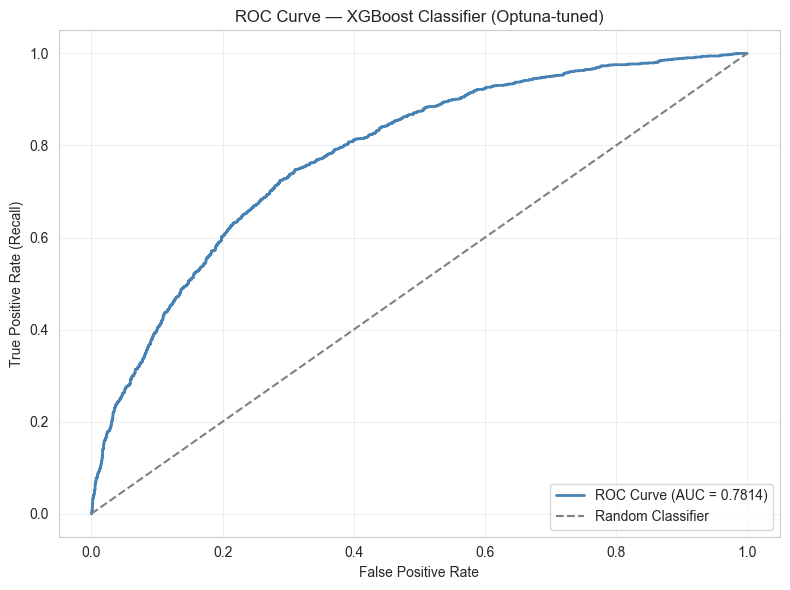

In [52]:
probabilities = model_xgb_best.predict_proba(X_test2)
fpr, tpr, thresholds = roc_curve(y_test2, probabilities[:, 1])
area = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {area:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — XGBoost Classifier (Optuna-tuned)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 22. Model Serialisation

All components required for inference are bundled into a single dictionary and serialised with `joblib`:

| Key | Contents |
|-----|----------|
| `scaler` | Fitted `MinMaxScaler` + list of scaled column names |
| `model_burnout_score` | Best regressor for `burnout_score` + its expected feature columns |
| `model_seeks_career_counseling` | Tuned XGBoost classifier + its IV-filtered feature columns |
| `model_overall_career_readiness_score` | Best regressor for `overall_career_readiness_score` + its expected feature columns |

Storing the column lists alongside each model ensures that inference code can correctly reorder or subset incoming feature DataFrames before prediction, preventing silent shape mismatches.

In [53]:
best = {
    'scaler': {
        'scaler': scaler,
        'cols': cols_to_scale
    },
    'model_burnout_score': {
        'model': model_lr1,
        'cols': X_train1.columns.tolist()
    },
    'model_seeks_career_counseling': {
        'model': model_xgb_best,
        'cols': X_train2.columns.tolist()
    },
    'model_overall_career_readiness_score': {
        'model': model_xgb_best2,
        'cols': X_train1.columns.tolist()
    }
}

In [54]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(best, "artifacts/models.pkl")

print("Saved to artifacts/models.pkl")

Saved to artifacts/models.pkl
